# 00 — open the data

**Goal of this first notebook:** just *open* the microstructure capture and
look at it honestly. No strategy, no signal — we answer four boring but
essential questions:

1. What sessions do we have on disk, and what's inside one?
2. What do the four streams (order book, trades, ticker, liquidations) actually
   look like — columns, a few real rows?
3. Is the data *sane* — how long did we capture, how fast is each stream, how
   laggy is the feed?
4. First picture: the BTC mid-price over the session, with the trade tape.

This is the microstructure sibling of `notebooks/*/00_smoke`. Same playbook
(`notebooks/pump/HOW_WE_WORK.md`): one small honest step, plots via `show()` →
read `_out/<name>.png`. Journal lives in `microstructure/initial/README.md`.

In [1]:
import sys; sys.path.insert(0, ".")   # cwd = microstructure/initial
from _lab import *

import pandas as pd
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

## 1. What's on disk?

The collector rolls each capture into a *session* directory:

```
data/bybit/micro/sessions/<session_id>/
    manifest.json                         # config, symbols, start/end, totals
    orderbook/<SYMBOL>/part-*.parquet     # one part per 60s flush
    trades/… ticker/… liquidations/…
```

`list_sessions()` lists them; `manifest()` reads the header of one.

In [2]:
sessions = list_sessions()
print(f"{len(sessions)} session(s) on disk:")
for s in sessions:
    m = manifest(s)
    dur_h = (pd.Timestamp(m["ended"]) - pd.Timestamp(m["started"])).total_seconds() / 3600
    print(f"  {s}  |  {dur_h:5.1f}h  |  {len(m['symbols'])} syms  |  "
          f"{m['totals']['rows']:>9,} rows  |  {m['totals']['bytes']/1e6:6.1f} MB")

3 session(s) on disk:
  2026-07-08T19-00-28Z  |    nanh  |  5 syms  |          0 rows  |     0.0 MB
  2026-07-08T19-06-02Z  |    2.9h  |  5 syms  |  1,085,533 rows  |   115.9 MB
  2026-07-09T08-03-30Z  |   14.3h  |  5 syms  |  4,879,318 rows  |   524.8 MB


The two 2026-07-08 sessions were short smoke-tests. The **2026-07-09** one is the
real capture — ~14 hours, 5 symbols, ~4.9M rows — so that's the one we explore.

In [3]:
SESS = "2026-07-09T08-03-30Z"
m = manifest(SESS)
print("session :", SESS)
print("market  :", m["market"])
print("symbols :", m["symbols"])
print("streams :", m["streams"])
print("depth   :", m["depth"], "levels/side")
print("book cadence :", m["sample_interval_ms"], "ms")
print("started :", m["started"])
print("ended   :", m["ended"])

session : 2026-07-09T08-03-30Z
market  : linear-perp
symbols : ['BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'SUIUSDT', 'TRXUSDT']
streams : ['orderbook', 'trades', 'ticker', 'liquidations']
depth   : 25 levels/side
book cadence : 250 ms
started : 2026-07-09T08:03:30.502666+00:00
ended   : 2026-07-09T22:21:50.816131+00:00


## 2. What does each stream look like?

`load(session, stream, symbol)` concatenates all the `part-*.parquet` files for
one (session, stream, symbol) and returns a time-sorted DataFrame. Every row
carries two timestamps in **milliseconds**:

- `ts_exchange` — when the event happened on Bybit (event time)
- `ts_local`   — when our collector received it (receipt time)

Let's load all four streams for **BTCUSDT** and look at shape + columns + a
couple of real rows.

In [4]:
SYM = "BTCUSDT"
ob   = load(SESS, "orderbook",    SYM, with_datetime=True)
tr   = load(SESS, "trades",       SYM, with_datetime=True)
tk   = load(SESS, "ticker",       SYM, with_datetime=True)
liq  = load(SESS, "liquidations", SYM, with_datetime=True)

for name, df in [("orderbook", ob), ("trades", tr), ("ticker", tk), ("liquidations", liq)]:
    print(f"{name:13s}: {df.shape[0]:>8,} rows  x {df.shape[1]:>3} cols")

orderbook    :  185,523 rows  x 103 cols
trades       : 1,325,127 rows  x   7 cols
ticker       :  375,103 rows  x  14 cols
liquidations :      175 rows  x   6 cols


### 2a. Order book — the *wide* top-25 snapshot

Every 250 ms we store the top 25 levels of each side, laid out flat:
`bid_px_0/bid_sz_0 … bid_px_24/bid_sz_24` and the same for asks. Level 0 is the
best (touch) price. So one row is a full snapshot of the visible book at that
instant. Showing just the top 3 levels each side to keep it readable.

In [5]:
cols3 = (["bid_px_0","bid_sz_0","bid_px_1","bid_sz_1","bid_px_2","bid_sz_2",
          "ask_px_0","ask_sz_0","ask_px_1","ask_sz_1","ask_px_2","ask_sz_2"])
ob[cols3].head(3)

,bid_px_0,bid_sz_0,bid_px_1,bid_sz_1,bid_px_2,bid_sz_2,ask_px_0,ask_sz_0,ask_px_1,ask_sz_1,ask_px_2,ask_sz_2
dt,,,,,,,,,,,,
2026-07-09 08:03:33.154000+00:00,62921.2,7.188,62921.1,0.001,62920.8,0.09,62921.3,0.124,62921.4,0.001,62921.9,0.001
2026-07-09 08:03:33.476000+00:00,62921.2,7.825,62921.1,0.001,62920.8,0.09,62921.3,0.120,62921.4,0.001,62921.8,0.002
2026-07-09 08:03:33.778000+00:00,62921.2,7.825,62921.1,0.001,62920.8,0.09,62921.3,0.120,62921.4,0.001,62921.8,0.002


### 2b. Trades — the tape

Every public trade Bybit broadcast: `price`, `amount` (in base coin, BTC here),
`side` (aggressor: `buy` = a market buy lifted the ask), and a unique `id`.

In [6]:
tr[["price","amount","side","id"]].head(5)

,price,amount,side,id
dt,,,,
2026-07-09 08:03:34.169000+00:00,62921.3,0.010,buy,b8b05629-de90-5274-b16d-dbfa6502d2e8
2026-07-09 08:03:34.169000+00:00,62921.3,0.010,buy,88e37d52-5422-5c61-b7d7-71597d4eaec5
2026-07-09 08:03:34.169000+00:00,62921.3,0.010,buy,7f0d835b-7991-564e-b0ce-3f9bb6e5e939
2026-07-09 08:03:34.169000+00:00,62921.3,0.010,buy,4fb2013c-d3fe-5b07-8903-401593f75a23
2026-07-09 08:03:34.169000+00:00,62921.3,0.001,buy,dce2b799-449b-5191-9d2c-2c7ab7ee4182


### 2c. Ticker — BBO + funding / open interest

A periodic snapshot: `last`, best `bid`/`ask` (+ their sizes), `mark`/`index`
price, `funding_rate`, `open_interest`, and rolling `base_volume`/`quote_volume`.
This is where funding & OI live — useful later for regime context.

In [7]:
tk[["last","bid","ask","mark","index","funding_rate","open_interest","quote_volume"]].head(3)

,last,bid,ask,mark,index,funding_rate,open_interest,quote_volume
dt,,,,,,,,
2026-07-09 08:03:33.156000+00:00,62921.2,62921.2,62921.3,62923.49,62949.25,0.0001,56397.63,4.981603e+09
2026-07-09 08:03:33.157000+00:00,62921.2,62921.2,62921.3,62924.65,62949.22,0.0001,56397.63,4.981603e+09
2026-07-09 08:03:33.313000+00:00,62921.2,62921.2,62921.3,62924.65,62949.22,0.0001,56397.63,4.981605e+09


### 2d. Liquidations — sparse forced exits

`side`, `price`, `amount`. These fire only when someone gets liquidated, so the
stream is mostly silent — often just a handful of rows over hours. (`amount` can
be `None` when the exchange doesn't report size.)

In [8]:
print(f"{len(liq)} liquidation events for {SYM} this session")
liq[["side","price","amount"]].head(5)

175 liquidation events for BTCUSDT this session


,side,price,amount
dt,,,
2026-07-09 08:39:58.770000+00:00,s,63378.7,None
2026-07-09 08:52:02.757000+00:00,s,62574.2,None
2026-07-09 08:52:25.756000+00:00,s,62549.9,None
2026-07-09 09:08:06.248000+00:00,s,63076.2,None
2026-07-09 09:08:07.249000+00:00,s,62515.4,None


## 3. Is the data sane?

Four cheap sanity checks before we ever trust a number built on top of this:

- **Coverage** — does each stream span the full ~14h, no big gaps?
- **Book cadence** — median gap between snapshots should be ≈ 250 ms (the
  configured sample rate).
- **Trade rate** — trades/minute, just to know how busy the tape is.
- **Feed lag** — `ts_local - ts_exchange`; the README expects ~0.5s.

In [9]:
def span(df):
    t = pd.to_datetime(df["ts_local"], unit="ms", utc=True)
    return t.min(), t.max(), (t.max() - t.min()).total_seconds() / 3600

for name, df in [("orderbook", ob), ("trades", tr), ("ticker", tk)]:
    a, b, h = span(df)
    print(f"{name:10s}: {a:%H:%M:%S} -> {b:%H:%M:%S}  ({h:.2f}h)")

print()
# book cadence: gap between consecutive snapshots
dt_book = ob["ts_local"].diff().dropna()
print(f"book snapshot gap  : median {dt_book.median():.0f} ms, "
      f"p95 {dt_book.quantile(0.95):.0f} ms  (target {m['sample_interval_ms']} ms)")

# trade rate
_, _, tr_h = span(tr)
print(f"trade rate         : {len(tr)/ (tr_h*60):.1f} trades/min")

# feed lag
for name, df in [("orderbook", ob), ("trades", tr)]:
    lag = feed_lag_ms(df)
    print(f"feed lag {name:9s} : median {lag.median()/1000:.2f}s, p95 {lag.quantile(0.95)/1000:.2f}s")

orderbook : 08:03:33 -> 22:21:50  (14.30h)
trades    : 08:03:34 -> 22:21:49  (14.30h)
ticker    : 08:03:33 -> 22:21:49  (14.30h)

book snapshot gap  : median 260 ms, p95 358 ms  (target 250 ms)
trade rate         : 1544.0 trades/min
feed lag orderbook : median 0.28s, p95 0.42s
feed lag trades    : median 0.28s, p95 0.41s


## 4. First picture — BTC mid price + the tape

The single most basic microstructure quantity: the **mid price**, halfway
between the best bid and best ask, `(bid_px_0 + ask_px_0) / 2`. We plot it over
the whole session and scatter the trades on top, coloured by aggressor side
(green = market buy, red = market sell). This is our "does it look like a real
market?" smoke test.

[saved] microstructure\initial\_out\00_btc_mid_tape.png


WindowsPath('C:/projects/researchlab/microstructure/initial/_out/00_btc_mid_tape.png')

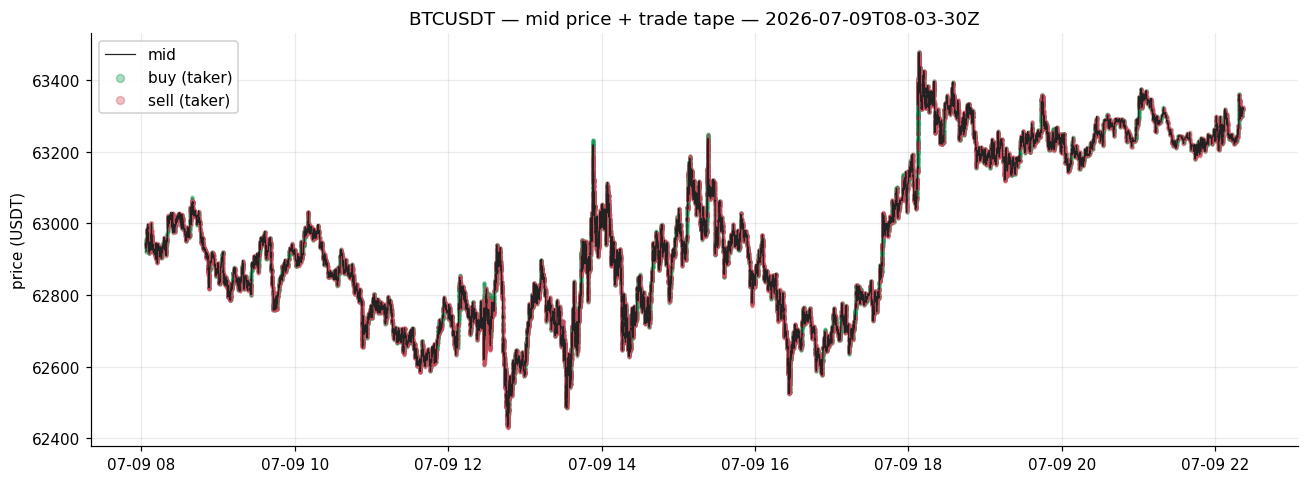

In [10]:
import matplotlib.pyplot as plt

m_px = mid(ob)
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(ob.index, m_px, lw=0.8, color="#222", label="mid", zorder=3)

# thin the tape so the scatter is legible
tr_s = tr.iloc[::20]
buys  = tr_s[tr_s["side"] == "buy"]
sells = tr_s[tr_s["side"] == "sell"]
ax.scatter(buys.index,  buys["price"],  s=3, c="#159a52", alpha=0.35, label="buy (taker)")
ax.scatter(sells.index, sells["price"], s=3, c="#d1495b", alpha=0.35, label="sell (taker)")

ax.set_title(f"{SYM} — mid price + trade tape — {SESS}")
ax.set_ylabel("price (USDT)")
ax.legend(loc="upper left", markerscale=3, framealpha=0.9)
show("00_btc_mid_tape")

## 5. Where we are

**Verdict:** the capture opens cleanly and looks like a real market — four
streams load via `microstructure.loader`, the book is a tidy top-25 snapshot
every ~250 ms, the tape is busy, and the mid price tracks the trades. Sanity
checks (coverage / cadence / lag) confirm the collector behaved.

**Honest caveats:** a single ~14h session, 5 symbols, one day. Liquidations are
very sparse (expected). Nothing here is a signal yet — just confirming the raw
material is trustworthy.

**Next step (nb 01):** build the core derived series from the book — spread,
top-N **order-book imbalance**, and short-horizon mid returns — and take a first
look at whether imbalance leads price on a seconds horizon. That's the classic
first microstructure question, and where an edge would live if there is one.